In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
from scipy.spatial import Delaunay

from random_matrix.amplitude_matrix import isotropic_sphere
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.scattering_matrix import sampler
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)



In [ ]:

def integrand(x,y):
    return x+y+z

print( integration_utils.basic_triangle_integral(
                    integrand, ([0,0],[1,0],[0,1]), scheme=None
                )
            )
        

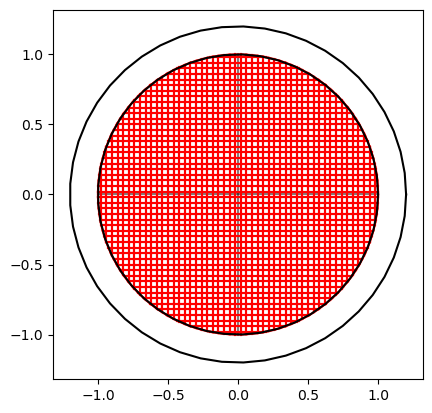

In [5]:
#seed = 0
#np.random.seed(seed)
side_length = 0.04

#warnings.filterwarnings("ignore")
my_grid = mode_grid_factory.from_tiling(
    tiling_type="rectangles",
    side_length=(side_length, side_length),
    r_lim=1.2,
    grid_wave_type="propagating",
    rotation_angle=0,
    translation_vector=np.array([0.0, 0.0]),
)
my_grid.plot(show_indices=False)


    
def Right_Es(kx, ky):
    p = np.array([1,0,0])
    kappa = np.sqrt(kx**2 + ky**2)
    es = np.stack([ky/kappa, -kx/kappa, np.zeros_like(kx)], axis=-1)
    return np.abs(1j*np.dot(es,p)/np.sqrt(1-kx**2 - ky**2))


def Right_Ep(kx, ky):
    p = np.array([1,0,0])
    kappa = np.sqrt(kx**2 + ky**2)
    kz = np.sqrt(1 - kx**2 - ky**2)
    ep = np.stack([kx*kz/kappa, ky*kz/kappa, -kappa], axis=-1)
    return np.abs(1j*np.dot(ep,p)/np.sqrt(1-kx**2 - ky**2))

def Left_Es(kx, ky):
    p = np.array([1,0,0])
    kappa = np.sqrt(kx**2 + ky**2)
    es = np.stack([ky/kappa, -kx/kappa, np.zeros_like(kx)], axis=-1)
    return np.abs(1j*np.dot(es,p)/np.sqrt(1-kx**2 - ky**2))

def Left_Ep(kx, ky):
    p = np.array([1,0,0])
    kappa = np.sqrt(kx**2 + ky**2)
    kz = np.sqrt(1 - kx**2 - ky**2)
    ep = np.stack([-kx*kz/kappa, -ky*kz/kappa, -kappa], axis=-1)
    return np.abs(1j*np.dot(ep,p)/np.sqrt(1-kx**2 - ky**2))




In [7]:
def dipole_field(my_grid):
    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]
    E_sr = []
    E_pr = []
    E_sl = []
    E_pl = []
    
    for unit_cell in vertices_list:
        # Perform Delaunay triangulation for the current square
        tri = Delaunay(unit_cell)
        triangle_indices = tri.simplices  # Indices of the triangle vertices
        triangle_vertices = unit_cell[
            triangle_indices
        ]  # Get the vertices of the triangles
        E_sr.append(
            np.sum(
                integration_utils.basic_triangle_integral(
                    Right_Es, triangle_vertices, scheme=None
                )
            )
        )
        E_pr.append(
            np.sum(
                integration_utils.basic_triangle_integral(
                    Right_Ep, triangle_vertices, scheme=None
                )
            )
        )
        E_sl.append(
            np.sum(
                integration_utils.basic_triangle_integral(
                    Left_Es, triangle_vertices, scheme=None
                )
            )
        )
        E_pl.append(
            np.sum(
                integration_utils.basic_triangle_integral(
                    Left_Ep, triangle_vertices, scheme=None
                )
            )
        )

    return np.array(E_sr), np.array(E_pr),np.array(E_sl),np.array(E_pl)  # Return the list as a numpy array




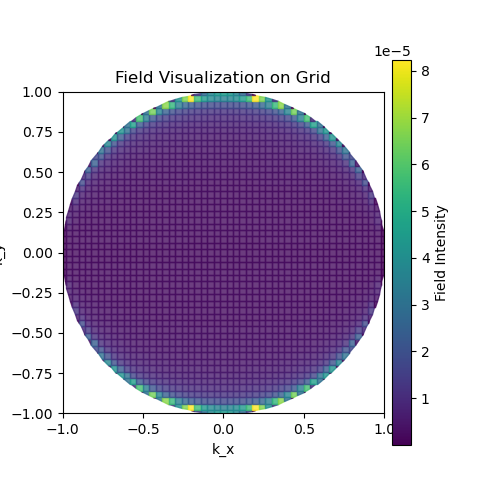

In [15]:
def plot_field_on_grid(my_grid, E):
    # Extract the vertices and indices of the grid
    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]
    indices = [mode.index for mode in my_grid.mode_list]

    # Create the plot
    plt.figure(figsize=(5, 5))
    for i, vertices in enumerate(vertices_list):
        # Get the corresponding field value for the current box
        field_value = E[i]

        # Create a polygon for the current box
        polygon = plt.Polygon(
            vertices, color=plt.cm.viridis(field_value / np.max(E)), alpha=0.8
        )

        # Add the polygon to the plot
        plt.gca().add_patch(polygon)

    # Set plot limits and aspect ratio
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().set_aspect("equal", adjustable="box")

    # Add a colorbar to the side
    sm = plt.cm.ScalarMappable(
        cmap="viridis", norm=plt.Normalize(vmin=np.min(E), vmax=np.max(E))
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), orientation="vertical", pad=0.02)
    cbar.set_label("Field Intensity")

    plt.title("Field Visualization on Grid")
    plt.xlabel("k_x")
    plt.ylabel("k_y")
    plt.show()

Esr,Epr,Esl,Epl = dipole_field(my_grid)
E = Esr**2 + Epr**2
plot_field_on_grid(my_grid, E)




In [9]:
def centres_of_cells(vertices_list):
    """
    Calculate the center of each square given its vertices.

    Parameters:
        vertices_list (list): A list of arrays, where each array contains the vertices of a square.

    Returns:
        list: A list of arrays, where each array represents the center of a square.
    """
    centres = []
    for vertices in vertices_list:
        # Calculate the mean of the vertices to find the center
        center = np.mean(vertices, axis=0)
        centres.append(center)
    return np.array(centres)


# Example usage
vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]
centres = centres_of_cells(vertices_list)


def xy_to_rt(x,y):
    """
    Convert Cartesian coordinates (x, y) to polar coordinates (r, theta).

    Parameters:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        tuple: A tuple containing the polar coordinates (r, theta).
    """

    # Extract x and y coordinates from the centres
    #x = 1/centres[:, 0]
    #y = 1/centres[:, 1]

    r = np.sqrt(x**2 + y**2)
    theta = -(np.pi / 2 - np.arctan2(y, x))  # Angle in radians
    return r, theta


In [10]:

kx = centres[:, 0]
ky = centres[:, 1]
kz = np.sqrt(1-(kx**2+ky**2))
Esr,Epr,Esl,Epl = dipole_field(my_grid)
Er = Esr**2 + Epr**2
El = Esl**2 + Epl**2
kx.shape

(2077,)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

def plot_3d_scatter(x, y, z, values1,values2, cmap='viridis'):
    """
    Plots a 3D scatter plot where color represents the function value.

    Parameters:
        x, y, z (array-like): Coordinates of the points in 3D space.
        values (array-like): Function values at each point.
        cmap (str): Colormap for coloring points.
    """



    plt.ion()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=values1, cmap=cmap, s=30)
    sc = ax.scatter(x, y, -z, c=values2, cmap=cmap, s=30)
    fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5, label='Function Value')

    ax.set_xlabel('kx')
    ax.set_ylabel('ky')
    ax.set_zlabel('kz')
    plt.title('3D Scatter Plot of Function Values')
    plt.show()


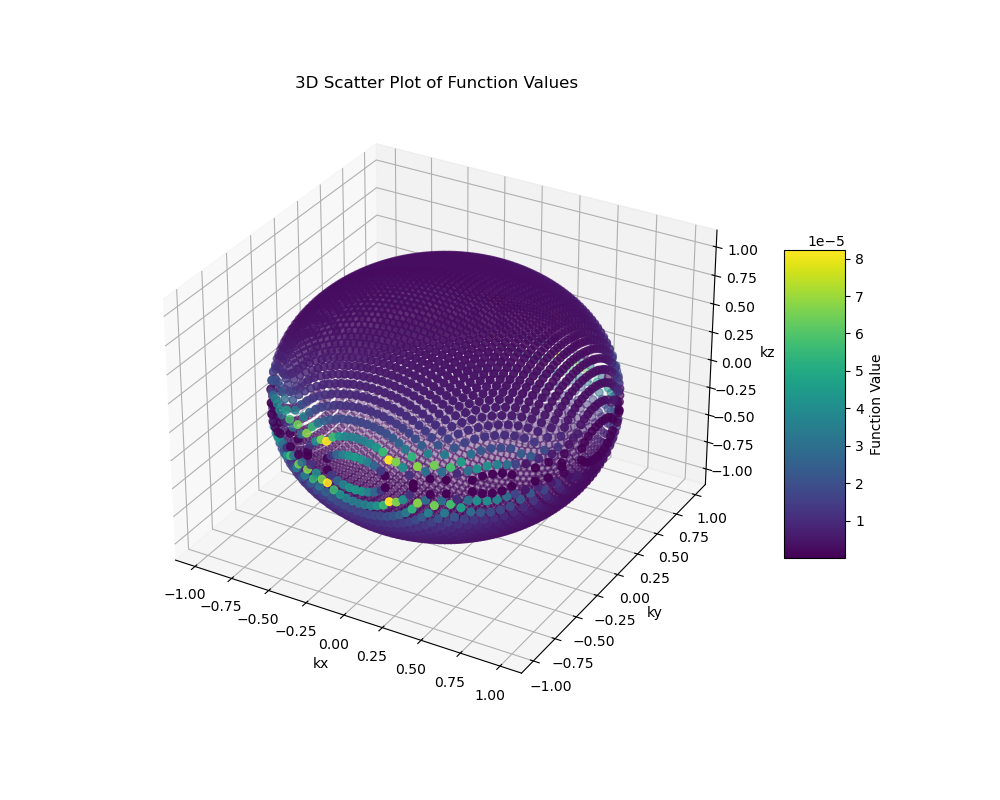

In [14]:
plot_3d_scatter(kx, ky, kz, Er,El, cmap='viridis')

In [ ]:

def anal_dipole_field(r, theta):
    Er = 2 * np.cos(theta) / (r**3)
    Et = np.sin(theta) / (r**3)
    return Er**2 + Et**2

/tmp/ipykernel_3629745/2039381942.py:2: RuntimeWarning: divide by zero encountered in divide
  Er = 2 * np.cos(theta) / (r**3)
/tmp/ipykernel_3629745/2039381942.py:3: RuntimeWarning: divide by zero encountered in divide
  Et = np.sin(theta) / (r**3)
/tmp/ipykernel_3629745/154831742.py:14: RuntimeWarning: invalid value encountered in scalar divide
  vertices, color=plt.cm.viridis(field_value / np.max(E)), alpha=0.8


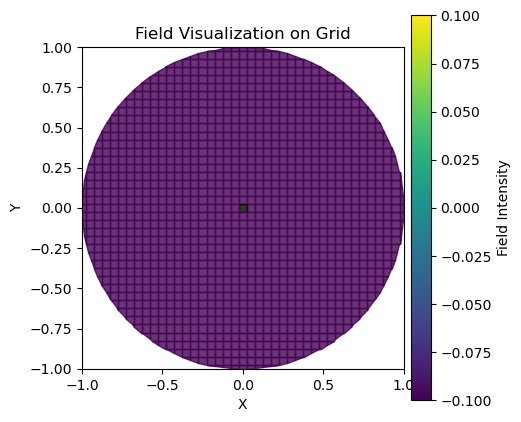

In [ ]:
x,y = centres[:, 0], centres[:, 1]
r,t = xy_to_rt(x,y)
E_anal = anal_dipole_field(r,t)
plot_field_on_grid(my_grid, E_anal)

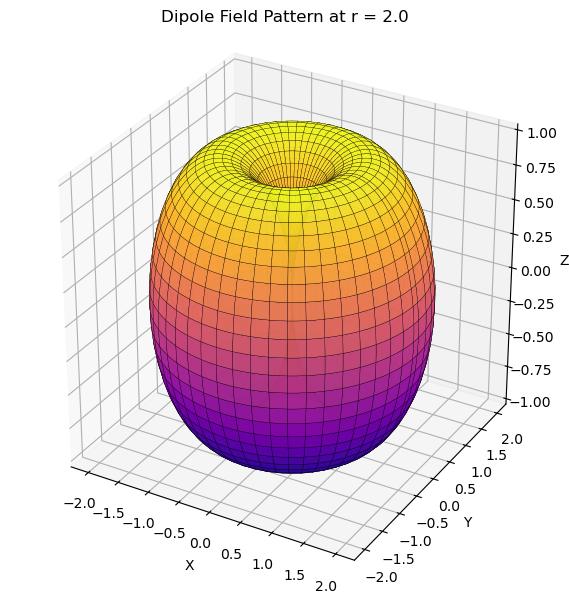

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_dipole_field(r=1.0, resolution=100, scale=1.0):
    """
    Plot the 3D doughnut shape of a dipole field.
    
    Parameters:
        r : float
            Radial distance from the origin.
        resolution : int
            Number of steps in theta and phi.
        scale : float
            Multiplies the field strength to scale the shape.
    """
    # Create spherical coordinates
    theta = np.linspace(0, np.pi, resolution)
    phi = np.linspace(0, 2 * np.pi, resolution)
    theta, phi = np.meshgrid(theta, phi)

    # Dipole field pattern: E ∝ sin(theta)
    E = scale * np.sin(theta)

    # Convert to Cartesian coordinates
    x = r * E * np.sin(theta) * np.cos(phi)
    y = r * E * np.sin(theta) * np.sin(phi)
    z = r * E * np.cos(theta)

    # Plotting
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z, cmap="plasma", edgecolor='k', linewidth=0.2, alpha=0.9)

    ax.set_title(f"Dipole Field Pattern at r = {r}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.show()
plot_dipole_field(r=2.0)

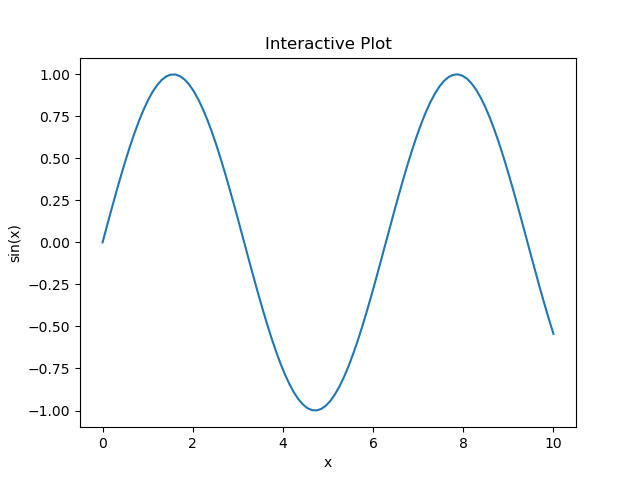

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

# Create a sample plot
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Interactive Plot")
plt.show()